# SST Demo: Running `workshop-sst`

This notebook is meant to live in the docs directory of the
[`chicago-aiscience/workshop-sst`](https://github.com/chicago-aiscience/workshop-sst)
repository. It will:

1. Import the SST package modules.
2. Run the SST ETL workflow using Python functions on the sample CSVs in `data/`.
3. Load the resulting CSV artifacts with pandas.
4. Plot a few time series using matplotlib.

**Command to install dependencies:**

`%pip install -e ".[dev]"`

> **Tip:** Make sure your working directory is the repo root (where `pyproject.toml` lives)
> when you install the dependencies to run. This uses the `pyproject.toml` in the repo and installs the `sst` CLI and Python package into your current environment.

In [1]:
# Environment checks
import sys
from pathlib import Path

# Get the repo root (parent of docs directory)
root = Path.cwd().parent
print("Python:", sys.version)
print("Working directory:", root)
print("Contents here:", [p.name for p in root.iterdir()])

Python: 3.13.9 (main, Oct 17 2025, 11:40:15) [Clang 16.0.0 (clang-1600.0.26.6)]
Working directory: /Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst
Contents here: ['.flake8', 'artifacts', 'mkdocs.yml', 'LICENSE', '.pytest_cache', '.pre-commit-config.yaml', 'Dockerfile', '.ruff_cache', 'pyproject.toml', 'tests', 'docs', 'README.md', '.dockerignore', '.mypy_cache', '.gitignore', '.venv', 'scripts', '.github', 'site', '.git', 'data', 'src']


# 1. Run the SST ETL workflow using the Python package

This imports the SST package modules and runs the ETL workflow directly,
writing artifacts into an `artifacts/` directory in the repo root.

Loading SST data...
Loading ENSO data...
Joining datasets...
Computing metrics...
✓ Wrote /Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst/artifacts/summary.csv
Creating trend plot...
✓ Wrote /Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst/artifacts/trends.png
Creating correlation plot...
✓ Wrote /Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst/artifacts/scatter_plot.png

Artifacts directory now contains:
[PosixPath('/Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst/artifacts/summary.csv'), PosixPath('/Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst/artifacts/scatter_plot.png'), PosixPath('/Users/ntebaldi/Documents/ai+science/workshops/workshop_1_github_actions/sst/artifacts/trends.png')]


/Users/ntebaldi/.pyenv/versions/3.13.9/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/ntebaldi/.pyenv/versions/3.13.9/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


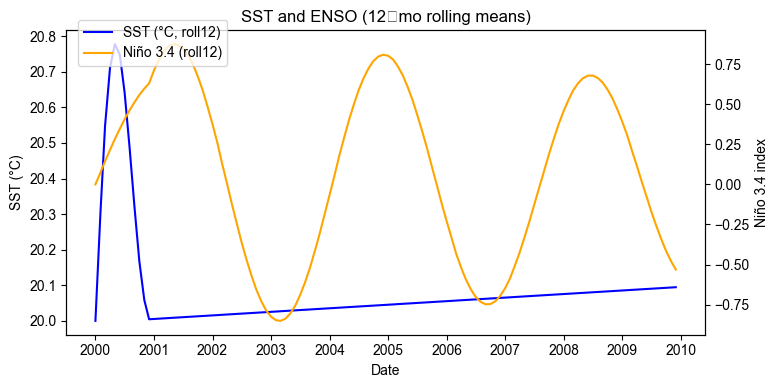

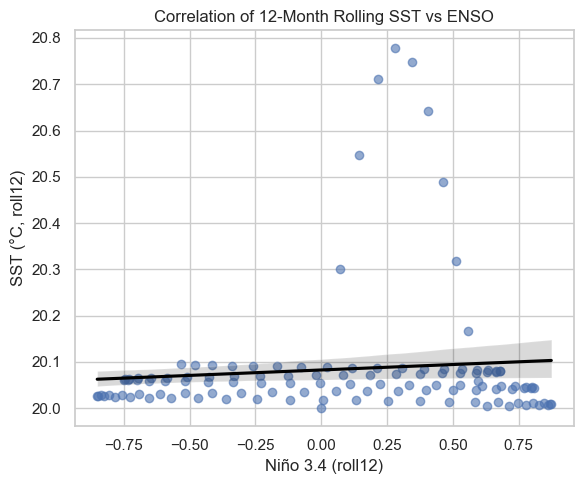

In [2]:
# Import the SST package modules
from sst.io import load_enso, load_sst
from sst.transform import join_on_month, metrics, tidy
from sst.plot import make_corr_plot, make_trend_plot
from pathlib import Path

# Set up paths
root = Path.cwd().parent
sst_path = root / "data" / "sst_sample.csv"
enso_path = root / "data" / "nino34_sample.csv"
out_dir = root / "artifacts"
out_dir.mkdir(parents=True, exist_ok=True)

# Run the ETL workflow
print("Loading SST data...")
sst_df = tidy(load_sst(sst_path), date_col="date", value_col="sst_c", roll=12)

print("Loading ENSO data...")
enso_df = tidy(load_enso(enso_path), date_col="date", value_col="nino34", roll=12)

print("Joining datasets...")
joined = join_on_month(sst_df, enso_df, start="2000-01")

print("Computing metrics...")
summary = metrics(joined)
summary_path = out_dir / "summary.csv"
summary.to_csv(summary_path, index=False)
print(f"✓ Wrote {summary_path}")

print("Creating trend plot...")
fig = make_trend_plot(joined)
trends_path = out_dir / "trends.png"
fig.savefig(trends_path, dpi=150, bbox_inches="tight")
print(f"✓ Wrote {trends_path}")

print("Creating correlation plot...")
fig = make_corr_plot(joined)
scatter_path = out_dir / "scatter_plot.png"
fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
print(f"✓ Wrote {scatter_path}")

print(f"\nArtifacts directory now contains:\n{list(out_dir.iterdir())}")

## 2. Explore the raw sample CSVs

We will load the SST and ENSO (Niño 3.4) sample CSVs from `data/` and
inspect their structure. The code below intentionally treats the first
column as a date/time index and any remaining columns as numeric values,
so it will stay robust even if column names are tweaked in the future.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path.cwd().parent

def load_time_series(path: Path) -> pd.DataFrame:
    """Generic helper: parse first column as datetime and set as index."""
    df = pd.read_csv(path, parse_dates=[0])
    df = df.set_index(df.columns[0]).sort_index()
    return df

sst_raw = load_time_series(root / "data" / "sst_sample.csv")
enso_raw = load_time_series(root / "data" / "nino34_sample.csv")

display("SST sample:")
display(sst_raw.head())

display("ENSO (Niño 3.4) sample:")
display(enso_raw.head())

'SST sample:'

,sst_c
date,
2000-01-01,20.000
2000-02-01,20.601
2000-03-01,21.041
2000-04-01,21.202
2000-05-01,21.043


'ENSO (Niño 3.4) sample:'

,nino34
date,
2000-01-01,0.000
2000-02-01,0.145
2000-03-01,0.288
2000-04-01,0.424
2000-05-01,0.551


### Plot the raw time series

We plot all numeric columns from each dataset against their datetime index.

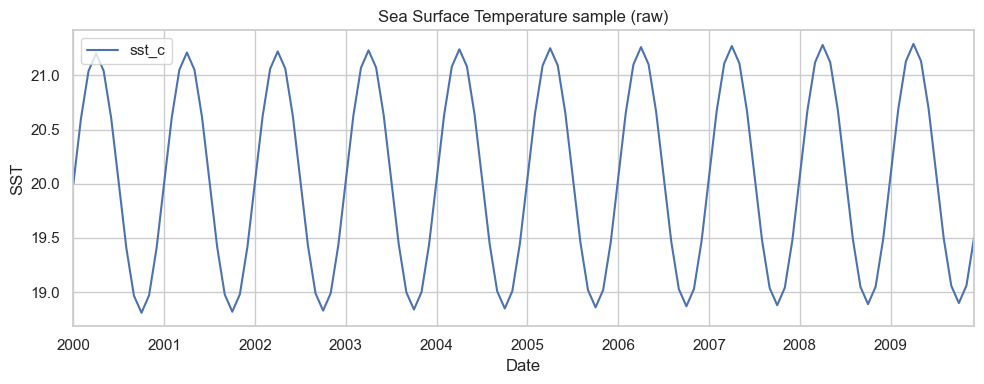

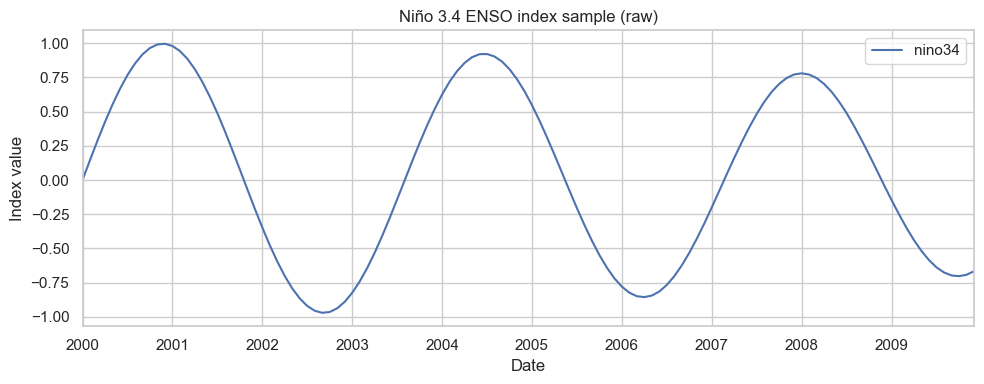

In [4]:
plt.figure(figsize=(10, 4))
sst_raw.select_dtypes("number").plot(ax=plt.gca())
plt.title("Sea Surface Temperature sample (raw)")
plt.xlabel("Date")
plt.ylabel("SST")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
enso_raw.select_dtypes("number").plot(ax=plt.gca())
plt.title("Niño 3.4 ENSO index sample (raw)")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.tight_layout()
plt.show()

## 3. Inspect and plot the ETL summary artifacts

After running the `sst` CLI, you should have at least a `summary.csv`
file in `artifacts/`. We will load that and plot all numeric columns
against the first (date-like) column, similar to the raw data step.

'Summary metrics:'

,sst_trend_c_per_decade,delta_sst_last_yr_c,delta_enso_last_yr,corr_sst_enso_roll,n_months
0,-0.118,0.01,-0.694,0.091,120


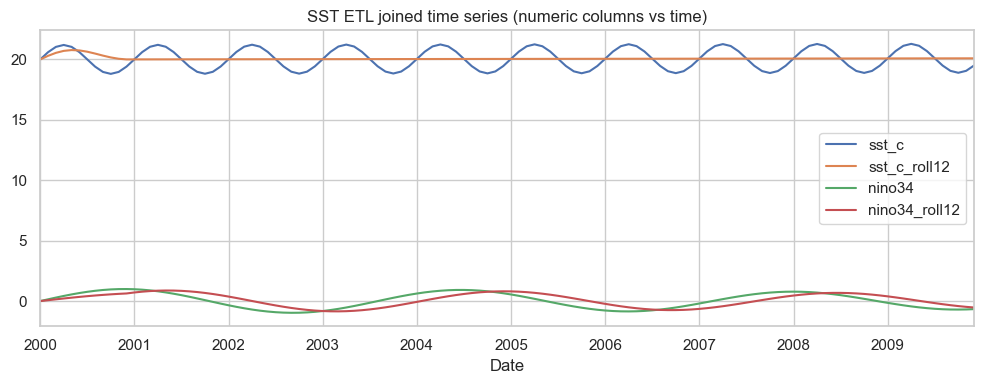

In [5]:
root = Path.cwd().parent
artifacts = root / "artifacts"
summary_path = artifacts / "summary.csv"

# Load the summary CSV (it's a single-row summary, not a time series)
summary = pd.read_csv(summary_path)
display("Summary metrics:")
display(summary)

# If you want to plot the joined time series instead:
from sst.io import load_enso, load_sst
from sst.transform import join_on_month, tidy

sst_df = tidy(load_sst(root / "data" / "sst_sample.csv"), date_col="date", value_col="sst_c", roll=12)
enso_df = tidy(load_enso(root / "data" / "nino34_sample.csv"), date_col="date", value_col="nino34", roll=12)
joined = join_on_month(sst_df, enso_df, start="2000-01")

plt.figure(figsize=(10, 4))
joined.set_index("date").select_dtypes("number").plot(ax=plt.gca())
plt.title("SST ETL joined time series (numeric columns vs time)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 4. (Optional) Display the generated trends figure

The CLI also writes a `trends.png` figure into `artifacts/`. If it
exists, we can display it inline as a quick visual check.

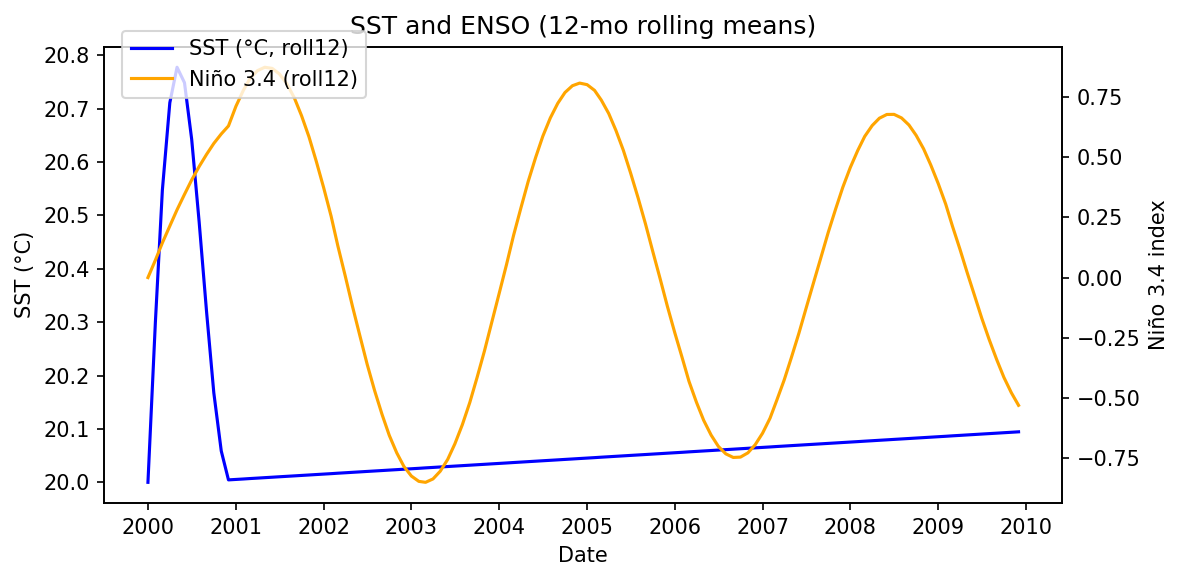

In [6]:
root = Path.cwd().parent
artifacts = root / "artifacts"
trends_path = artifacts / "trends.png"

if trends_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(trends_path)))
else:
    print("No trends.png found in artifacts/")